In [4]:
"""
生成美化版的 EX1/EX2/EX3 组合图
- Fast@3 vs p_thr
- Speedup@3 vs p_thr

优化点：
1. 行列标题化（行=EX, 列=dataset size）
2. 只留外侧坐标轴
3. Legend 移到顶部，弱化网格，减少 markers
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ==================== 配置 ====================

# NOTE: Jupyter 里没有 __file__，所以用 cwd。
# 你只需要确保 notebook 的 cwd 在你的 repo 内（最好就是 repo 根目录），否则手动改成 repo 根目录即可。
WORKSPACE_ROOT = Path("/projects/kzhou6/bcui2/git_submit/ICLR_26")

# WORKSPACE_ROOT = Path("/absolute/path/to/your/repo/root")  # <- 如果你想固定就取消注释改这里

TABLES_DIR = WORKSPACE_ROOT / "analysis_summaries" / "tables"
OUTPUT_DIR = WORKSPACE_ROOT / "analysis_summaries" / "beautiful_figure" / "main_paper"

# 确保输出目录存在
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EX_VERSIONS = ['EX1', 'EX2', 'EX3']
DATASET_SIZES = ['mini', 'small', 'medium', 'large', 'extra-large']
MODELS = ['claude', 'gpt5.1', 'qwen']

# 模型颜色和标签
MODEL_COLORS = {
    'claude': '#2E86AB',
    'gpt5.1': '#A23B72',
    'qwen': '#F18F01'
}

MODEL_LABELS = {
    'claude': 'Claude',
    'gpt5.1': 'GPT-4o',
    'qwen': 'Qwen'
}

# Dataset 标签
DATASET_LABELS = {
    'mini': 'Mini',
    'small': 'Small',
    'medium': 'Medium',
    'large': 'Large',
    'extra-large': 'Extra-Large'
}

In [9]:
# ==================== 数据加载 ====================

def load_ex1_ex2_data():
    """加载 EX1/EX2 的 Fast@k 和 Speedup@k 数据"""
    data = {}

    for ex in ['EX1', 'EX2']:
        data[ex] = {}
        for ds in DATASET_SIZES:
            table_file = TABLES_DIR / f"table_e_paper_level_k3_{ex}_{ds}.csv"
            if not table_file.exists():
                print(f"[WARN] 未找到: {table_file.name}")
                continue

            df = pd.read_csv(table_file)

            # EX2 需要筛选 threads=16
            if ex == 'EX2':
                df = df[df['threads'] == 16.0]

            data[ex][ds] = df

    return data


def load_ex3_data():
    """加载 EX3 的 Fast@3 和 Speedup@3 数据"""
    # 尝试从 unified_data 目录加载
    ex3_file_1 = WORKSPACE_ROOT / "analysis_summaries" / "unified_data" / "fast_speedup_at_k3_with_pthr_EX3.csv"
    ex3_file_2 = TABLES_DIR / "fast_speedup_at_k3_with_pthr_EX3.csv"

    ex3_file = ex3_file_1 if ex3_file_1.exists() else ex3_file_2

    if not ex3_file.exists():
        print(f"[ERROR] 未找到 EX3 数据文件")
        print(f"  尝试过: {ex3_file_1}")
        print(f"  尝试过: {ex3_file_2}")
        return {}

    print(f"  ✓ 读取 EX3 数据: {ex3_file.name}")
    df = pd.read_csv(ex3_file)

    # 按 benchmark, model, dataset, p_thr 聚合
    data = {}
    for ds in DATASET_SIZES:
        df_ds = df[df['dataset'] == ds]

        if len(df_ds) == 0:
            print(f"    [WARN] {ds}: 无数据")
            continue

        # 按 model 和 p_thr 聚合（平均）
        df_agg = df_ds.groupby(['model', 'p_thr']).agg({
            'fast_at_3': 'mean',
            'speedup_at_3': 'mean'
        }).reset_index()

        data[ds] = df_agg
        print(f"    ✓ {ds}: {len(df_agg)} 行数据")

    return data


# ==================== 绘图函数 ====================

def plot_combined_fast_at_k(ex1_ex2_data, ex3_data):
    """绘制 Fast@3 组合图（3行5列）"""

    fig, axes = plt.subplots(3, 5, figsize=(15, 8), dpi=150)

    # 调整子图间距
    plt.subplots_adjust(
        left=0.055, right=0.985,
        top=0.80, bottom=0.9,
        hspace=0.15, wspace=0.15
    )

    # 遍历每个 EX 和 dataset
    for row_idx, ex in enumerate(EX_VERSIONS):
        for col_idx, ds in enumerate(DATASET_SIZES):
            ax = axes[row_idx, col_idx]

            # 绘制数据
            if ex in ['EX1', 'EX2']:
                if ds in ex1_ex2_data[ex]:
                    df_e = ex1_ex2_data[ex][ds]

                    for model in MODELS:
                        df_model = df_e[df_e['model'] == model]
                        if len(df_model) > 0:
                            ax.plot(
                                df_model['p_thr'],
                                df_model['Fast_at_k_avg'],
                                color=MODEL_COLORS[model],
                                linewidth=2,
                                marker=None,  # 不显示 marker，只保留线条
                                markersize=0,
                                alpha=0.85
                            )

            elif ex == 'EX3':
                if ds in ex3_data:
                    df_ex3 = ex3_data[ds]

                    for model in MODELS:
                        df_model = df_ex3[df_ex3['model'] == model].sort_values('p_thr')
                        if len(df_model) > 0:
                            ax.plot(
                                df_model['p_thr'],
                                df_model['fast_at_3'],
                                color=MODEL_COLORS[model],
                                linewidth=2,
                                marker=None,  # 不显示 marker
                                markersize=0,
                                alpha=0.85
                            )

            # 网格（只保留水平网格，且更淡）
            ax.grid(True, axis='y', alpha=0.15, linestyle='-', linewidth=0.4, color='gray')
            ax.set_axisbelow(True)

            # 设置 y 轴范围
            ax.set_ylim(-0.05, 1.05)

            # 只在最左侧显示 y 轴标签
            if col_idx == 0:
                ax.set_ylabel('', fontsize=10)
            else:
                ax.set_yticklabels([])

            # 只在最下方显示 x 轴标签
            if row_idx == 2:
                ax.set_xlabel('', fontsize=10)
            else:
                ax.set_xticklabels([])

            # 列标题（只在第一行显示）
            if row_idx == 0:
                ax.set_title(DATASET_LABELS[ds], fontsize=11, fontweight='normal', pad=15)

            # 调整刻度字体大小
            ax.tick_params(axis='both', labelsize=8)

    # 添加行标签（竖着放在左侧）
    row_labels = ['EX1 (Serial)', 'EX2 (OpenMP)', 'EX3 (CUDA)']
    row_positions = [0.77, 0.50, 0.23]  # 对应三行的中心位置
    for row_idx, label in enumerate(row_labels):
        fig.text(
            0.02, row_positions[row_idx],
            label,
            fontsize=12,
            fontweight='bold',
            ha='center',
            va='center',
            rotation=90
        )

    # 添加总的 x 轴和 y 轴标签
    fig.text(0.53, 0.03, r'Speedup threshold $p_{\mathrm{thr}}$',
             ha='center', fontsize=13, fontweight='normal')
    fig.text(0.005, 0.5, r'Fast@3',
             ha='center', va='center', rotation=90, fontsize=13, fontweight='normal')

    # Legend 放在顶部中央
    handles = [
        plt.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=2.5,
                   marker='o', markersize=5, label=MODEL_LABELS[m])
        for m in MODELS
    ]

    fig.legend(
        handles=handles,
        loc='upper center',
        ncol=3,
        frameon=True,
        fontsize=11,
        bbox_to_anchor=(0.5, 1.02),
        columnspacing=1.5,
        handlelength=2.5
    )

    # 保存
    output_file = OUTPUT_DIR / "figure_fast_at_3_beautiful.pdf"
    plt.savefig(output_file, bbox_inches='tight', dpi=300)
    print(f"✓ 保存: {output_file}")

    # NOTE: notebook 里希望直接看到图，所以 show 一下
    plt.show()
    plt.close()


def plot_combined_speedup_at_k(ex1_ex2_data, ex3_data):
    """绘制 Speedup@3 组合图（3行5列）"""

    fig, axes = plt.subplots(3, 5, figsize=(15, 8), dpi=150)

    # 调整子图间距
    plt.subplots_adjust(
        left=0.08, right=0.98,
        top=0.92, bottom=0.9,
        hspace=0.15, wspace=0.15
    )

    # 遍历每个 EX 和 dataset
    for row_idx, ex in enumerate(EX_VERSIONS):
        for col_idx, ds in enumerate(DATASET_SIZES):
            ax = axes[row_idx, col_idx]

            # 绘制数据
            if ex in ['EX1', 'EX2']:
                if ds in ex1_ex2_data[ex]:
                    df_e = ex1_ex2_data[ex][ds]

                    for model in MODELS:
                        df_model = df_e[df_e['model'] == model]
                        if len(df_model) > 0:
                            ax.plot(
                                df_model['p_thr'],
                                df_model['Speedup_at_k_avg'],
                                color=MODEL_COLORS[model],
                                linewidth=2,
                                marker=None,  # 不显示 marker
                                markersize=0,
                                alpha=0.85
                            )

            elif ex == 'EX3':
                if ds in ex3_data:
                    df_ex3 = ex3_data[ds]

                    for model in MODELS:
                        df_model = df_ex3[df_ex3['model'] == model].sort_values('p_thr')
                        if len(df_model) > 0:
                            ax.plot(
                                df_model['p_thr'],
                                df_model['speedup_at_3'],
                                color=MODEL_COLORS[model],
                                linewidth=2,
                                marker=None,  # 不显示 marker
                                markersize=0,
                                alpha=0.85
                            )

            # 网格（只保留水平网格，且更淡）
            ax.grid(True, axis='y', alpha=0.15, linestyle='-', linewidth=0.4, color='gray')
            ax.set_axisbelow(True)

            # 只在最左侧显示 y 轴标签
            if col_idx == 0:
                ax.set_ylabel('', fontsize=10)
            else:
                ax.set_yticklabels([])

            # 只在最下方显示 x 轴标签
            if row_idx == 2:
                ax.set_xlabel('', fontsize=10)
            else:
                ax.set_xticklabels([])

            # 列标题（只在第一行显示）
            if row_idx == 0:
                ax.set_title(DATASET_LABELS[ds], fontsize=11, fontweight='normal', pad=15)

            # 调整刻度字体大小
            ax.tick_params(axis='both', labelsize=8)

    # 添加行标签（竖着放在左侧）
    row_labels = ['EX1 (Serial)', 'EX2 (OpenMP)', 'EX3 (CUDA)']
    row_positions = [0.77, 0.50, 0.23]  # 对应三行的中心位置
    for row_idx, label in enumerate(row_labels):
        fig.text(
            0.02, row_positions[row_idx],
            label,
            fontsize=12,
            fontweight='bold',
            ha='center',
            va='center',
            rotation=90
        )

    # 添加总的 x 轴和 y 轴标签
    fig.text(0.53, 0.03, r'Speedup threshold $p_{\mathrm{thr}}$',
             ha='center', fontsize=13, fontweight='normal')
    fig.text(0.005, 0.5, r'Speedup@3',
             ha='center', va='center', rotation=90, fontsize=13, fontweight='normal')

    # Legend 放在顶部中央
    handles = [
        plt.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=2.5,
                   marker='o', markersize=5, label=MODEL_LABELS[m])
        for m in MODELS
    ]

    fig.legend(
        handles=handles,
        loc='upper center',
        ncol=3,
        frameon=True,
        fontsize=11,
        bbox_to_anchor=(0.5, 1.02),
        columnspacing=1.5,
        handlelength=2.5
    )

    # 保存
    output_file = OUTPUT_DIR / "figure_speedup_at_3_beautiful.pdf"
    plt.savefig(output_file, bbox_inches='tight', dpi=300)
    print(f"✓ 保存: {output_file}")

    # NOTE: notebook 里希望直接看到图，所以 show 一下
    plt.show()
    plt.close()


生成美化版 EX1/EX2/EX3 组合图

加载数据...
  ✓ 读取 EX3 数据: fast_speedup_at_k3_with_pthr_EX3.csv
    ✓ mini: 48 行数据
    ✓ small: 48 行数据
    ✓ medium: 48 行数据
    ✓ large: 48 行数据
    ✓ extra-large: 48 行数据
✓ 数据加载完成

绘制 Fast@3 图...


ValueError: bottom cannot be >= top

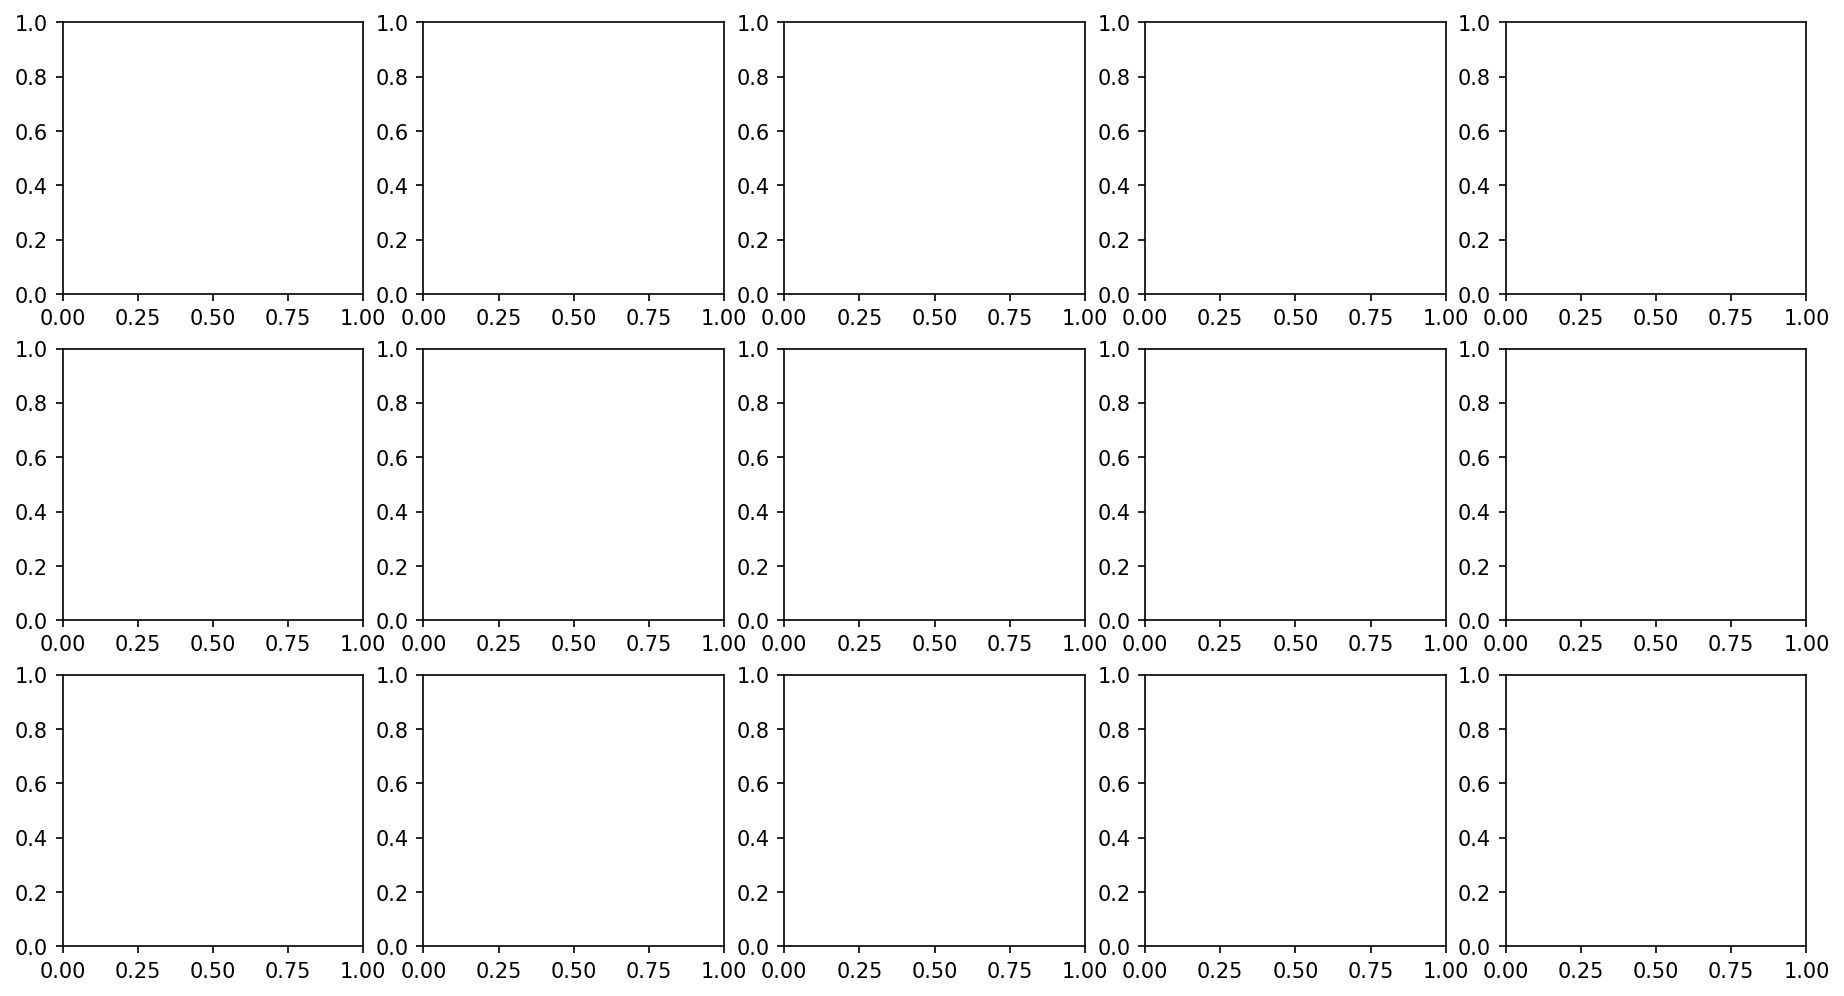

In [10]:
print("="*80)
print("生成美化版 EX1/EX2/EX3 组合图")
print("="*80)
print()

# 加载数据
print("加载数据...")
ex1_ex2_data = load_ex1_ex2_data()
ex3_data = load_ex3_data()
print("✓ 数据加载完成")
print()

# 绘制 Fast@3 图
print("绘制 Fast@3 图...")
plot_combined_fast_at_k(ex1_ex2_data, ex3_data)
print()

# 绘制 Speedup@3 图
print("绘制 Speedup@3 图...")
plot_combined_speedup_at_k(ex1_ex2_data, ex3_data)
print()

print("="*80)
print("✅ 完成！")
print("="*80)
print()
print(f"输出目录: {OUTPUT_DIR}")
